<a href="https://colab.research.google.com/github/werowe/HypatiaAcademy/blob/master/ml/step_by_step_single_neural_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is an Activation Function?

Imagine your brain processing information. Each neuron gets a bunch of signals, adds them up, and then decides whether to "fire" a new signal or not. An **activation function** in a neural network works similarly to that "decision-making" part of a neuron.

It takes the raw sum of inputs (what we called `z = w * x + b`) and transforms it into a useful output, often a probability or a clear 'yes'/'no' signal.

### The Sigmoid Function: Our Decision Maker

In our case, we're using the `sigmoid` function. Here's what it does:

`sigmoid(z) = 1 / (1 + torch.exp(-z))`

**Think of it like this:**

*   **Input (`z`):** This `z` value can be any number – very big positive, very big negative, or somewhere in the middle.
*   **Output (`sigmoid(z)`):** The sigmoid function takes that `z` and squashes it into a number strictly between **0 and 1**. It never quite reaches 0 or 1, but it gets extremely close.

**Why is this useful?**

1.  **Probabilities:** Because its output is always between 0 and 1, we can easily interpret it as a **probability**. For example, if `sigmoid(z)` gives us `0.85`, we can say there's an 85% chance of 'yes'.

2.  **Smooth Transitions:** Instead of a sharp cut-off (like if `z` is > 0, output is 1; else output is 0), the sigmoid function provides a smooth curve. This smoothness is crucial because it allows our model to learn gradually. If it were a sharp cut-off, it would be much harder to figure out *how much* to adjust `w` and `b` to improve our predictions.

**Here's a quick idea of what it does:**

*   If `z` is a very large positive number (e.g., 100), `sigmoid(z)` will be very close to `1` (high probability of 'yes').
*   If `z` is `0`, `sigmoid(z)` will be exactly `0.5` (50/50 chance).
*   If `z` is a very large negative number (e.g., -100), `sigmoid(z)` will be very close to `0` (low probability of 'yes').

So, the sigmoid function acts as a translator, converting the raw numerical score (`z`) into a meaningful probability (`y_hat`) that helps us make decisions.

#Sigmoid
Gives a probability between 0 and 1

$σ(z) = \frac{1}{1 + e^{-z}}$

which is the same as :

$σ(z) = \frac{1}{1 + (1/ e^{z})}$

where:

$z = mx + b$

![](https://raw.githubusercontent.com/werowe/HypatiaAcademy/master/images/sigmoid.png)

# Here is Python code to plot the Sigmoid Function

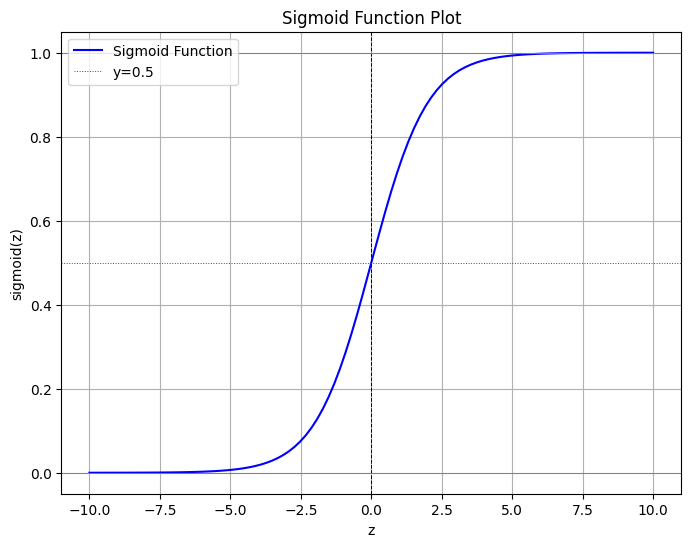

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define the sigmoid function
def sigmoid_np(z):
    return 1 / (1 + np.exp(-z))

# Generate x values from -10 to 10
x_vals = np.linspace(-10, 10, 100)

# Calculate y values using the sigmoid function
y_vals = sigmoid_np(x_vals)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Sigmoid Function', color='blue')
plt.title('Sigmoid Function Plot')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid(True)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7) # Add x=0 line
plt.axhline(0.5, color='red', linestyle=':', linewidth=0.7, label='y=0.5') # Add y=0.5 line
plt.axhline(0, color='gray', linestyle='-', linewidth=0.7) # Add y=0 line
plt.axhline(1, color='gray', linestyle='-', linewidth=0.7) # Add y=1 line
plt.legend()
plt.show()

In [3]:
import torch

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))


## The Loss Function


The `loss` function, specifically the **Binary Cross-Entropy Loss**, is like a scoring system that tells us *how wrong* our model's guess (`y_hat`) is compared to the actual correct answer (`y`). We want this score to be as low as possible.

Here's the formula we use:


$L(\hat{y}, y) = -\left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)
$


Let's break down why it looks like that:

*   `y` is the **correct answer** (always 0 or 1).
*   `ŷ` is **our model's prediction** (a number between 0 and 1, like 0.9 or 0.2).

This formula cleverly focuses on just one part at a time, depending on the correct answer:

1.  **If `y = 1` (The correct answer was 'YES'):**
    *   The formula becomes: `L = -(1 * log(y_hat) + (0) * log(1 - y_hat))`, which simplifies to `L = -log(y_hat)`.
    *   **Think:** If `y_hat` was high (e.g., 0.9, a good guess), then `log(0.9)` is a small negative number. Taking `-log(0.9)` gives a small positive "wrongness" score. Good!
    *   **Think:** If `y_hat` was low (e.g., 0.1, a bad guess), then `log(0.1)` is a large negative number. Taking `-log(0.1)` gives a large positive "wrongness" score. Bad!
    *   So, if the answer was 'yes', we want our guess `y_hat` to be close to 1. The further away it is, the higher our "wrongness" score.

2.  **If `y = 0` (The correct answer was 'NO'):**
    *   The formula becomes: `L = -(0 * log(y_hat) + (1) * log(1 - y_hat))`, which simplifies to `L = -log(1 - y_hat)`.
    *   **Think:** If `y_hat` was low (e.g., 0.1, a good guess for 'no'), then `1 - y_hat` is high (0.9). `log(0.9)` is a small negative number. Taking `-log(0.9)` gives a small positive "wrongness" score. Good!
    *   **Think:** If `y_hat` was high (e.g., 0.9, a bad guess for 'no'), then `1 - y_hat` is low (0.1). `log(0.1)` is a large negative number. Taking `-log(0.1)` gives a large positive "wrongness" score. Bad!
    *   So, if the answer was 'no', we want our guess `y_hat` to be close to 0. The further away it is, the higher our "wrongness" score.

**Why `log`?**

The `log` function (specifically natural logarithm here) is powerful because it gives us a big penalty for being very confidently wrong. If your model guesses `y_hat = 0.99` when the answer was actually `y = 0`, that's a *very* confident wrong answer, and the `log` function makes that "wrongness" score shoot up dramatically. It helps the model learn to avoid being overconfident about incorrect predictions.

In short, this loss function pushes our model to make confident *correct* predictions and strongly punishes confident *incorrect* predictions, which is exactly what we want for a good classifier!

$L(\hat{y}, y) = -\left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)
$

In [4]:
def loss(y_hat, y):
    return -(y * torch.log(y_hat) + (1 - y) * torch.log(1 - y_hat))


## Why this is a Neural Network with A Single Neuron

This is indeed a neural network with **just one neuron**. The fact that `w` (weights) has a size of 3 doesn't mean there are three neurons; it means there are **three features in your input `x`**.

Let's break it down:

*   **Input `x = [1.0, 2.0, 3.0]`**: These are your three input features (different pieces of information).
*   **Weights `w = torch.rand(3)`**: You need one weight for *each* input feature. So, `w[0]` will be multiplied by `x[0]`, `w[1]` by `x[1]`, and `w[2]` by `x[2]`. This means your `w` needs to have the same number of elements as your `x`.
*   **`z = torch.dot(w, x) + b`**: The `torch.dot(w, x)` part performs a sum of (weight * feature) for all three features. It looks like `(w[0]*x[0]) + (w[1]*x[1]) + (w[2]*x[2])`. This entire sum results in a **single number `z`**.
*   **`y_hat = sigmoid(z)`**: This `sigmoid` function then takes that single number `z` and squashes it into a single probability `y_hat` (your prediction).

Since all the inputs are combined into a single `z` which then feeds into a single `sigmoid` to produce a single `y_hat`, this entire setup acts like **one single neuron** in a neural network. It's often called **logistic regression** when used for binary classification, and logistic regression is essentially the simplest form of a neural network (a single-layer perceptron with a sigmoid activation).

In [5]:
# input features
x = torch.tensor([1.0, 2.0, 3.0])

# actual observed output value
y = torch.tensor(1.0)

# initialize weights
w = torch.rand(3)

print("\ninitial weights", w)

# initialize bias
b = torch.tensor(0.0)

print("\ninitial bias", b)


initial weights tensor([0.2214, 0.6606, 0.1251])

initial bias tensor(0.)


In [6]:

def forward_pass(w, x, b, y):
    # calculate z, the linear output
    z = torch.dot(w, x) + b

    # calculate the activation, this is also the prediction y_hat
    y_hat = sigmoid(z)

    # calculate the loss
    l = loss(y_hat, y)

    return y_hat, y, w, b, l


## How We Figure Out *How* to Adjust Our Guesses for Student Grades (`db` and `dw`)

Remember, our goal is to make our "wrongness score" (the loss) for predicting student success as small as possible. To do that, we need to know how changing our `w` (weights for features) and `b` (bias) will affect that score. This is where `db` and `dw` come in – they are like instructions telling us which way to nudge `w` and `b`.

Our prediction `y_hat` (probability of passing) comes from a two-step process:
1.  **`z = w * x + b`**: This is a simple calculation combining our student's features (`x`), their importance (`w`), and a baseline (`b`). It's like summing up all the influences on their grade.
2.  **`y_hat = sigmoid(z)`**: This `sigmoid` function takes `z` and squashes it into a probability between 0 and 1.

### Understanding `db = y_hat - y` (How to adjust the Bias)

`db` tells us how much we need to change our `b` (bias) to lower the "wrongness" score. It's the derivative of the loss with respect to `b`.

Let's break down *why* it's `y_hat - y`:

Imagine you have a "wrongness" score `L` (Loss). We need to see how `b` affects `L`. It's a chain reaction:
`b` changes `z` (because `z = w*x + b`) --> `z` changes `y_hat` (because `y_hat = sigmoid(z)`) --> `y_hat` changes `L`.

When you do the math (using a technique called the **Chain Rule**, like following steps in a recipe):

1.  **How much `L` changes if `y_hat` changes?** (The `∂L/∂y_hat` part)
    *   This is a bit complex, but for our specific "wrongness" formula, it works out to `(y_hat - y) / (y_hat * (1 - y_hat))`. Don't worry too much about the exact form for now, just know it's a measure of how sensitive the wrongness is to our prediction.
2.  **How much `y_hat` changes if `z` changes?** (The `∂y_hat/∂z` part)
    *   The `sigmoid` function has a cool property: its slope (how much it changes) is `y_hat * (1 - y_hat)`. When `y_hat` is close to 0 or 1, the sigmoid is flat (not very sensitive), but in the middle (around 0.5), it's steep (very sensitive).
3.  **How much `z` changes if `b` changes?** (The `∂z/∂b` part)
    *   Since `z = w * x + b`, if `b` goes up by 1, `z` also goes up by 1. So, this part is simply `1`.

Now, if we multiply these parts together:
`db = [ (y_hat - y) / (y_hat * (1 - y_hat)) ] * [ y_hat * (1 - y_hat) ] * [ 1 ]`

Notice how `y_hat * (1 - y_hat)` cancels out! 🎉

So, we are left with:
`db = y_hat - y`

**Intuition:**
*   If `y_hat` (our predicted probability of passing) is *higher* than `y` (the actual outcome), `db` will be positive. We then subtract `lr * db` from `b`, so `b` will decrease. This makes our `z` smaller, pushing `y_hat` down, closer to `y`.
*   If `y_hat` is *lower* than `y`, `db` will be negative. Subtracting a negative means `b` will increase. This makes our `z` larger, pushing `y_hat` up, closer to `y`.

### Understanding `dw = (y_hat - y) * x` (How to adjust the Weights for Student Features)

`dw` tells us how much we need to change our `w` (weights for each student feature) to lower the "wrongness" score. It's the derivative of the loss with respect to `w`.

The first two parts of the chain rule are the same as for `db`: `[ (y_hat - y) / (y_hat * (1 - y_hat)) ] * [ y_hat * (1 - y_hat) ]`, which simplifies to `y_hat - y`.

But for the last part:

*   **How much `z` changes if `w` changes?** (The `∂z/∂w` part)
    *   Since `z = w * x + b`, if `w` (the weight for a specific feature) goes up by 1, `z` goes up by `x` (the value of that specific feature). So, this part is simply `x`.

Multiplying everything together:
`dw = (y_hat - y) * x`

**Intuition:**
*   It's similar to `db`, using `y_hat - y` to tell us the direction of change needed for our prediction.
*   But it also multiplies by `x`! Why? Because each weight `w` is tied to a specific student feature `x`. If a student's 'hours studied' (`x`) is a large number, changing its corresponding `w` will have a *bigger impact* on `z` (and thus `y_hat`) than if 'hours studied' was a small number. So, `x` helps us scale how much we adjust `w` based on how influential that student feature was for the current prediction.

In short, `db` and `dw` are clever ways to get specific instructions on how to tweak our model's `w` (feature importances) and `b` (baseline bias) after each prediction to make its next guess about student success a little bit better, eventually leading to a very accurate model!

In [7]:
def back_propagation(y_hat, y, w, b):
    # gradients
    db = y_hat - y
    dw = (y_hat - y) * x

    # learning rate
    lr = 0.1

    # update weight and bias
    b = b - lr * db
    w = w - lr * dw

    return w, b

# Now Loop until we get Minimum Loss

In [8]:
# how many times to loop
cnt = 100

while cnt > 0:
    y_hat, y, w, b, l = forward_pass(w, x, b, y)

    if cnt % 5 == 0:
        print("loss", l.item())

    w, b = back_propagation(y_hat, y, w, b)

    cnt -= 1


print("\nfinal weights", w)
print("\nfinal bias", b)

print("\nnow make prediction")

y_hat = sigmoid(torch.dot(w, x) + b)

print("\npredicted value y_hat", y_hat.item())
print("\nobserved value y", y.item())

# and since it's logistic regression
if y_hat > 0.5:
    print("\nlogistic regression", True)
else:
    print("\nlogistic regression", False)

loss 0.1370636224746704
loss 0.06853923201560974
loss 0.04550110921263695
loss 0.03401399403810501
loss 0.02714414708316326
loss 0.022577283903956413
loss 0.019322993233799934
loss 0.0168869961053133
loss 0.014995450153946877
loss 0.013484446331858635
loss 0.012249625287950039
loss 0.011221731081604958
loss 0.010352850891649723
loss 0.009608566761016846
loss 0.00896418560296297
loss 0.00840057898312807
loss 0.007903614081442356
loss 0.007462140638381243
loss 0.007067322731018066
loss 0.006712143775075674

final weights tensor([0.4302, 1.0781, 0.7515])

final bias tensor(0.2088)

now make prediction

predicted value y_hat 0.9936293959617615

observed value y 1.0

logistic regression True


## Using PyTorch to Calculate Gradients

Instead of manually calculating `db` and `dw` as we did in the `back_propagation` function, PyTorch can automatically figure out these gradients for us using a feature called `autograd`. This is incredibly powerful for more complex neural networks, and simplifies the development process.

To use `autograd`, we just need to tell PyTorch which tensors we want to calculate gradients for by setting `requires_grad=True` when we define them. Then, after we calculate our loss, we simply call `.backward()` on the loss tensor, and PyTorch will compute all the necessary gradients.

In [9]:
# Re-initialize our inputs and parameters for PyTorch's autograd
# Input features - x does not require gradients as it's an input
x_autograd = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)

# Actual observed output value
y_autograd = torch.tensor(1.0, dtype=torch.float32)

# Initialize weights and bias, telling PyTorch to track operations on them
# so it can calculate gradients later.
w_autograd = torch.rand(3, requires_grad=True)
b_autograd = torch.tensor(0.0, requires_grad=True)

print("\nWeights for autograd:", w_autograd)
print("Bias for autograd:", b_autograd)

# Perform the forward pass with these new tensors
# PyTorch automatically builds a computation graph to track operations
z_autograd = torch.dot(w_autograd, x_autograd) + b_autograd
y_hat_autograd = sigmoid(z_autograd)
loss_autograd = loss(y_hat_autograd, y_autograd)

print("\nInitial prediction (y_hat) with autograd tensors:", y_hat_autograd.item())
print("Initial loss with autograd tensors:", loss_autograd.item())


Weights for autograd: tensor([0.7112, 0.2414, 0.4299], requires_grad=True)
Bias for autograd: tensor(0., requires_grad=True)

Initial prediction (y_hat) with autograd tensors: 0.9230002164840698
Initial loss with autograd tensors: 0.08012580871582031


In [10]:
# Perform the backward pass to compute gradients
loss_autograd.backward()

# Now, the gradients are stored in the .grad attribute of the tensors
print("\nGradients for weights (dw_autograd):", w_autograd.grad)
print("Gradients for bias (db_autograd):", b_autograd.grad)

# Compare these with the manually calculated gradients for context (if applicable)
# dw_manual = (y_hat_autograd - y_autograd) * x_autograd
# db_manual = y_hat_autograd - y_autograd

# print("\nManual dw:", dw_manual)
# print("Manual db:", db_manual)


Gradients for weights (dw_autograd): tensor([-0.0770, -0.1540, -0.2310])
Gradients for bias (db_autograd): tensor(-0.0770)
